# Data Cleaning and Exploratory Data Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots display in the notebook
%matplotlib inline

# Improve plot appearance
sns.set_theme(style="whitegrid")

## 2. Load Data

In [2]:
recipes = pd.read_csv("../Data/RAW_recipes.csv")
interactions = pd.read_csv("../Data/RAW_interactions.csv")

## 3. Dataset Overview

In [3]:
# Basic information about the datasets
print("Recipes dataset shape:", recipes.shape)
print("Interactions dataset shape:", interactions.shape)

display(recipes.head())
display(interactions.head())

Recipes dataset shape: (231637, 12)
Interactions dataset shape: (1132367, 5)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


Before cleaning the data, we examine the structure, data types, missing values, and potential duplicate records in both datasets.

In [4]:
# Data types and non-null counts
print("RECIPES DATASET")
recipes.info()

print("\nINTERACTIONS DATASET")
interactions.info()

RECIPES DATASET
<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         231637 non-null  int64
 8   steps           231637 non-null  str  
 9   description     226658 non-null  str  
 10  ingredients     231637 non-null  str  
 11  n_ingredients   231637 non-null  int64
dtypes: int64(5), str(7)
memory usage: 21.2 MB

INTERACTIONS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    11

In [5]:
# Missing values
recipe_missing = pd.DataFrame({
    "Missing Count": recipes.isna().sum(),
    "Missing Percent": (recipes.isna().mean() * 100).round(2)
})

interaction_missing = pd.DataFrame({
    "Missing Count": interactions.isna().sum(),
    "Missing Percent": (interactions.isna().mean() * 100).round(2)
})

print("Recipes - Missing Values")
display(recipe_missing.sort_values("Missing Count", ascending=False))

print("Interactions - Missing Values")
display(interaction_missing.sort_values("Missing Count", ascending=False))

Recipes - Missing Values


,Missing Count,Missing Percent
description,4979,2.15
name,1,0.00
id,0,0.00
minutes,0,0.00
contributor_id,0,0.00
submitted,0,0.00
tags,0,0.00
nutrition,0,0.00
n_steps,0,0.00
steps,0,0.00


Interactions - Missing Values


,Missing Count,Missing Percent
review,169,0.01
user_id,0,0.00
recipe_id,0,0.00
date,0,0.00
rating,0,0.00


In [6]:
# Check duplicates
print("Duplicate recipe rows:", recipes.duplicated().sum())
print("Duplicate interaction rows:", interactions.duplicated().sum())

# Check duplicate recipe IDs
print("Duplicate recipe IDs:", recipes["id"].duplicated().sum())

# Check rating values
print("Rating values:", sorted(interactions["rating"].unique()))

Duplicate recipe rows: 0
Duplicate interaction rows: 0
Duplicate recipe IDs: 0
Rating values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 4. Data Cleaning

The initial inspection indicates that both datasets are relatively complete, with no fully duplicated records or duplicate recipe IDs. Missing values are concentrated in recipe descriptions, with a small number of missing recipe names and interaction reviews.

The following section prepares the data for exploratory analysis and subsequent modeling while preserving information that may be useful for the recommendation system.

In [7]:
recipes_clean = recipes.copy()
interactions_clean = interactions.copy()

### 4.1 Convert dates

In [8]:
recipes_clean["submitted"] = pd.to_datetime(
    recipes_clean["submitted"], errors="coerce"
)

interactions_clean["date"] = pd.to_datetime(
    interactions_clean["date"], errors="coerce"
)

print("Invalid recipe dates:", recipes_clean["submitted"].isna().sum())
print("Invalid interaction dates:", interactions_clean["date"].isna().sum())

Invalid recipe dates: 0
Invalid interaction dates: 0


### 4.2 Handle the one missing recipe name

In [9]:
recipes_clean[recipes_clean["name"].isna()]

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
721,NaN,368257,10,779451,2009-04-27,"['15-minutes-or-less', 'time-to-make', 'course...","[1596.2, 249.0, 155.0, 0.0, 2.0, 112.0, 14.0]",6,"['in a bowl , combine ingredients except for o...",-------------,"['lemon', 'honey', 'horseradish mustard', 'gar...",10


In [10]:
recipes_clean["name"] = recipes_clean["name"].fillna("Unknown Recipe")
recipes_clean["name"].isna().sum()

np.int64(0)

One recipe was missing its name while retaining valid information for its ingredients, preparation steps, nutrition, and cooking time. Rather than removing the observation, the missing name was labeled `"Unknown Recipe"` to preserve potentially useful information for downstream analysis and modeling.

### 4.3 Investigate the 0 ratings

In [11]:
interactions_clean["rating"].value_counts().sort_index()

rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

In [12]:
(interactions_clean["rating"].value_counts(normalize=True)
 * 100).sort_index().round(2)

rating
0     5.37
1     1.13
2     1.25
3     3.61
4    16.55
5    72.09
Name: proportion, dtype: float64

In [13]:
zero_ratings = interactions_clean[
    interactions_clean["rating"] == 0
]

print("Number of zero ratings:", len(zero_ratings))
display(zero_ratings.head(10))

Number of zero ratings: 60847


,user_id,recipe_id,date,rating,review
6,124416,120345,2011-08-06,0,"Just an observation, so I will not rate. I fo..."
12,468945,134728,2008-02-20,0,Made my own buttermilk w/ vinegar and milk. U...
23,681408,225241,2008-03-14,0,This is a very good recipe. We also want to c...
39,2002068522,29093,2018-03-26,0,i made it and it was amazing
56,980899,79222,2010-10-18,0,"I used half cream and half 1% milk, added anot..."
63,1874846,79222,2011-04-04,0,FABULOUS!<br/><br/>I could not afford any of t...
66,1802697284,79222,2014-11-16,0,Awesome chowder! I used both canned and imitat...
67,2002097693,79222,2018-04-05,0,Do you have cook the potatoes beforehand?
119,1232945,487707,2012-10-08,0,Loved this salsa flavored meatloaf...tang is a...
134,2001891832,183729,2018-04-30,0,There is no cooking temp?????? Love this recip...


In [14]:
print(
    "Zero ratings with reviews:",
    zero_ratings["review"].notna().sum()
)

print(
    "Zero ratings without reviews:",
    zero_ratings["review"].isna().sum()
)

Zero ratings with reviews: 60847
Zero ratings without reviews: 0


In [15]:
zero_ratings[
    zero_ratings["review"].notna()
][["rating", "review"]].head(20)

,rating,review
6,0,"Just an observation, so I will not rate. I fo..."
12,0,Made my own buttermilk w/ vinegar and milk. U...
23,0,This is a very good recipe. We also want to c...
39,0,i made it and it was amazing
56,0,"I used half cream and half 1% milk, added anot..."
63,0,FABULOUS!<br/><br/>I could not afford any of t...
66,0,Awesome chowder! I used both canned and imitat...
67,0,Do you have cook the potatoes beforehand?
119,0,Loved this salsa flavored meatloaf...tang is a...
134,0,There is no cooking temp?????? Love this recip...


Approximately 5.37% of interactions have a rating of 0. Examination of these records shows that all zero-rated interactions contain written reviews, including many clearly positive comments. This suggests that a rating of 0 does not represent a true zero-star preference, but rather an interaction without an explicit 1–5 rating.

Therefore, zero-rated interactions are retained in the cleaned interaction dataset to preserve potentially useful interaction and review information. However, they will be excluded from analyses and models that treat ratings as explicit measures of user preference.

In [16]:
# Keep only explicit 1–5 ratings for rating-based analysis and modeling
ratings_clean = interactions_clean[
    interactions_clean["rating"].between(1, 5)
].copy()

print("All interactions:", len(interactions_clean))
print("Explicit ratings:", len(ratings_clean))
print("Excluded zero ratings:", len(interactions_clean) - len(ratings_clean))

All interactions: 1132367
Explicit ratings: 1071520
Excluded zero ratings: 60847


### 4.5 Check suspicious numerical values

In [17]:
recipes_clean[["minutes", "n_steps", "n_ingredients"]].describe()

,minutes,n_steps,n_ingredients
count,2.316370e+05,231637.000000,231637.000000
mean,9.398546e+03,9.765499,9.051153
std,4.461963e+06,5.995128,3.734796
min,0.000000e+00,0.000000,1.000000
25%,2.000000e+01,6.000000,6.000000
50%,4.000000e+01,9.000000,9.000000
75%,6.500000e+01,12.000000,11.000000
max,2.147484e+09,145.000000,43.000000


Summary statistics indicate potential anomalies in recipe preparation time. While the median recipe takes 40 minutes and 75% take 65 minutes or less, the maximum recorded preparation time exceeds two billion minutes. We therefore examine the upper tail of the preparation-time distribution before determining an appropriate cleaning rule.

In [18]:
# Examine extreme cooking times
recipes_clean[
    ["name", "id", "minutes", "n_steps", "n_ingredients"]
].sort_values("minutes", ascending=False).head(20)

,name,id,minutes,n_steps,n_ingredients
144074,no bake granola balls,261647,2147483647,9,8
109624,how to preserve a husband,447963,1051200,9,2
106563,homemade fruit liquers,291571,288000,12,3
38116,celtic druid s honey mead meade metheglin,216215,259260,18,7
106963,homemade vanilla,425681,259205,9,2
155044,peach brandy,98912,216015,9,4
5497,angelica liqueur,70551,201610,7,7
177906,rumtopf,12931,187200,16,8
170999,raspberry liqueur,172114,172810,7,3
53721,cinnamon extract,153634,172800,5,2


In [19]:
print("0-minute recipes:",
      (recipes_clean["minutes"] == 0).sum())

print("0-step recipes:",
      (recipes_clean["n_steps"] == 0).sum())

display(
    recipes_clean.loc[
        recipes_clean["minutes"] == 0,
        ["name", "minutes", "n_steps", "n_ingredients", "steps"]
    ].head(10)
)

0-minute recipes: 1094
0-step recipes: 1


,name,minutes,n_steps,n_ingredients,steps
5,apple a day milk shake,0,4,4,"['combine ingredients in blender', 'cover and ..."
2451,acorn magic delights,0,13,7,"['melt the butter or margarine over low heat',..."
3079,albanian byrek,0,14,9,"['prepare the dough with flour , 1 and a half ..."
3193,alfredo sauce with pasta,0,8,6,['cook noodles or fettuccine according to pack...
3259,alice s doughnuts,0,17,9,"['in a large bowl , beat the eggs until foamy'..."
3417,all bran seed loaf,0,10,11,"['stir together flour , baking powder , salt a..."
3440,all in one tuna casserole,0,5,7,"['preheat oven to 350 degrees f', 'in large bo..."
3571,almond bread,0,11,4,"['beat egg whites until very stiff', 'graduall..."
4889,americana key lime pie,0,18,13,"['thoroughly mix gelatin , 1 / 2 cup sugar , a..."
4918,amish biscuits,0,9,8,"['in a large bowl combine flour , baking soda ..."


In [20]:
# Treat invalid preparation times as missing
invalid_minutes = (
    (recipes_clean["minutes"] == 0) |
    (recipes_clean["minutes"] == 2147483647)
)

print("Invalid preparation times:", invalid_minutes.sum())

recipes_clean.loc[invalid_minutes, "minutes"] = np.nan

Invalid preparation times: 1095


In [21]:
recipes_clean["minutes"].describe()

count    2.305420e+05
mean     1.282515e+02
std      2.953313e+03
min      1.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      1.051200e+06
Name: minutes, dtype: float64

A total of 1,094 recipes were recorded with a preparation time of zero minutes. Inspection showed that many of these recipes contain multiple preparation or cooking steps, indicating that zero does not represent a plausible duration. These values were therefore treated as unknown preparation times and replaced with missing values rather than removing the recipes.

Together with the single implausible maximum value of 2,147,483,647 minutes, 1,095 preparation-time values were treated as invalid. Legitimately long preparation times, such as those associated with aging or fermenting recipes, were retained.

In [22]:
recipes_clean.loc[
    recipes_clean["n_steps"] == 0,
    ["name", "id", "minutes", "n_steps",
     "steps", "ingredients", "description"]
]

,name,id,minutes,n_steps,steps,ingredients,description
3381,all season bread,176767,90.0,0,[],"['flour', 'baking soda', 'salt', 'baking powde...",just change the fruit/vegetable in this recipe...


One recipe contains zero recorded preparation steps. Inspection confirmed that its `steps` field is an empty list, although other recipe information such as ingredients, preparation time, and description is available. The recipe was retained, and the zero-step value was left unchanged because it accurately reflects the available source data.

In [23]:
# Final cleaning validation
print("Recipes:", recipes_clean.shape)
print("Interactions:", interactions_clean.shape)
print("Explicit ratings:", ratings_clean.shape)

print("\nMissing values after cleaning:")
print(recipes_clean.isna().sum())

print("\nRating range:",
      ratings_clean["rating"].min(),
      "to",
      ratings_clean["rating"].max())

print("\nDuplicate recipe IDs:",
      recipes_clean["id"].duplicated().sum())

print("Duplicate interaction rows:",
      interactions_clean.duplicated().sum())

Recipes: (231637, 12)
Interactions: (1132367, 5)
Explicit ratings: (1071520, 5)

Missing values after cleaning:
name                 0
id                   0
minutes           1095
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

Rating range: 1 to 5

Duplicate recipe IDs: 0
Duplicate interaction rows: 0


## 5. Exploratory Data Analysis

This section explores recipe characteristics and user-rating behavior to identify patterns relevant to the development of the recommendation system. The analysis focuses on rating distributions, user and recipe interaction frequency, recipe characteristics, and relationships between recipe features and user preferences.

### 5.1 Rating Distribution

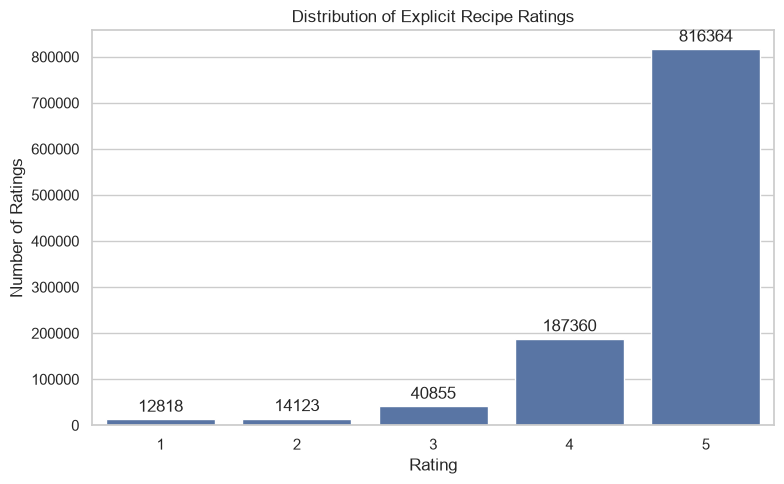

In [92]:
rating_counts = ratings_clean["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Distribution of Explicit Recipe Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()

plt.savefig(
    "../reports/figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
rating_summary = pd.DataFrame({
    "Count": rating_counts,
    "Percent": (rating_counts / rating_counts.sum() * 100).round(2)
})

rating_summary

,Count,Percent
rating,,
1,12818,1.20
2,14123,1.32
3,40855,3.81
4,187360,17.49
5,816364,76.19


Explicit ratings are heavily concentrated at the upper end of the rating scale. Rating 5 accounts for 76.19% of all explicit ratings, followed by rating 4 at 17.49%. Together, ratings of 4 and 5 represent approximately 93.68% of all explicit ratings. In contrast, ratings of 1–3 collectively account for only 6.32%.

This strong positive skew indicates substantial rating imbalance in the dataset. Consequently, overall prediction accuracy alone may provide a misleading assessment of model performance, since a model biased toward predicting high ratings could perform well without effectively distinguishing individual user preferences.

### 5.2 Ratings per user

In [26]:
user_activity = (
    ratings_clean.groupby("user_id")
    .size()
    .sort_values(ascending=False)
)

user_activity.describe()

count    196098.000000
mean          5.464207
std          52.722613
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7665.000000
dtype: float64

In [27]:
print("Unique users:", ratings_clean["user_id"].nunique())
print("Median ratings per user:", user_activity.median())
print("Users with only 1 rating:", (user_activity == 1).sum())
print("Maximum ratings by one user:", user_activity.max())

Unique users: 196098
Median ratings per user: 1.0
Users with only 1 rating: 140318
Maximum ratings by one user: 7665


User activity is highly sparse and right-skewed. Among 196,098 users with explicit ratings, the median user provided only one rating, and 140,318 users (approximately 71.6%) provided exactly one rating. In contrast, the most active user provided 7,665 ratings. This indicates that a relatively small group of highly active users contributes a disproportionate share of the available preference information.

This sparsity presents a cold-start challenge for personalized recommendation because most users provide very limited historical information from which to estimate their preferences.

### 5.3 Ratings per recipe

In [28]:
recipe_activity = (
    ratings_clean.groupby("recipe_id")
    .size()
    .sort_values(ascending=False)
)

recipe_activity.describe()

count    226590.000000
mean          4.728894
std          16.582369
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1496.000000
dtype: float64

In [29]:
print("Unique rated recipes:", ratings_clean["recipe_id"].nunique())
print("Median ratings per recipe:", recipe_activity.median())
print("Recipes with only 1 rating:", (recipe_activity == 1).sum())
print("Maximum ratings for one recipe:", recipe_activity.max())

Unique rated recipes: 226590
Median ratings per recipe: 2.0
Recipes with only 1 rating: 91698
Maximum ratings for one recipe: 1496


Recipe interaction frequency is also highly right-skewed. Among 226,590 recipes with explicit ratings, the median recipe received only two ratings, while 91,698 recipes (approximately 40.5%) received only one. In contrast, the most frequently rated recipe received 1,496 ratings.

This imbalance indicates that preference estimates for many recipes will be based on very limited evidence. A Bayesian approach is particularly relevant in this setting because uncertainty can be represented explicitly, allowing predictions based on sparse observations to carry greater uncertainty than predictions supported by many ratings.

### 5.4 Recipe Preparation Time

Preparation time is examined to understand the time commitment associated with recipes. Because the distribution contains legitimately long-duration recipes, such as aged or fermented foods and beverages, the visualization is restricted to the 95th percentile for readability while retaining these observations in the dataset.

In [30]:
recipes_clean["minutes"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2.305420e+05
mean     1.282515e+02
std      2.953313e+03
min      1.000000e+00
50%      4.000000e+01
75%      6.500000e+01
90%      1.350000e+02
95%      2.550000e+02
99%      9.200000e+02
max      1.051200e+06
Name: minutes, dtype: float64

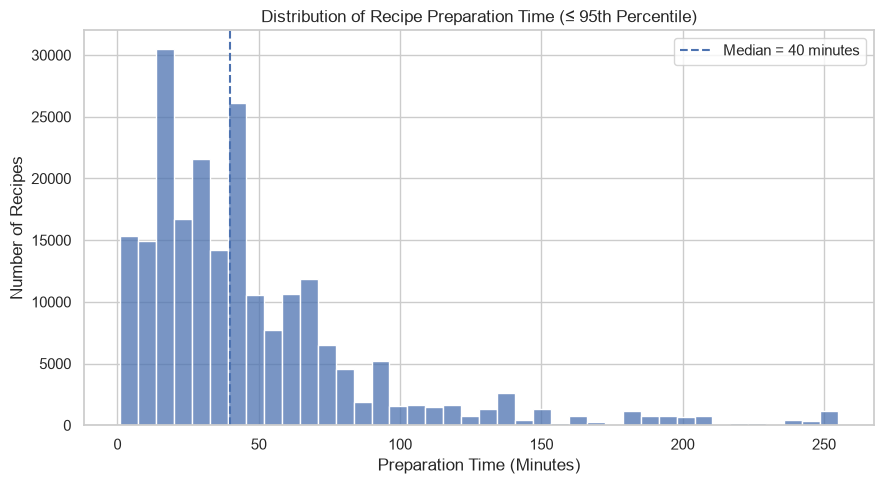

In [31]:
# 95th percentile of preparation time
minutes_95 = recipes_clean["minutes"].quantile(0.95)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=recipes_clean[recipes_clean["minutes"] <= minutes_95],
    x="minutes",
    bins=40
)

plt.axvline(
    recipes_clean["minutes"].median(),
    linestyle="--",
    label="Median = 40 minutes"
)

plt.title("Distribution of Recipe Preparation Time (≤ 95th Percentile)")
plt.xlabel("Preparation Time (Minutes)")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

Recipe preparation time is strongly right-skewed. The median recipe requires 40 minutes, and 75% of recipes require 65 minutes or less. However, the mean preparation time is substantially higher at approximately 128 minutes because a relatively small number of recipes have very long preparation periods. The visualization is limited to the 95th percentile (255 minutes) to better display the preparation times of most recipes without removing longer-duration recipes from the dataset.

Preparation time may therefore be a useful feature for recommendation, as users may differ substantially in their preferences for quick versus time-intensive recipes.

### 5.5 Recipe Complexity

The number of ingredients and preparation steps are examined as indicators of recipe complexity. Recipes requiring more ingredients or steps may involve greater preparation effort, which could influence user preferences and recommendations.

In [32]:
recipes_clean[["n_ingredients", "n_steps"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,n_ingredients,n_steps
count,231637.000000,231637.000000
mean,9.051153,9.765499
std,3.734796,5.995128
min,1.000000,0.000000
50%,9.000000,9.000000
75%,11.000000,12.000000
90%,14.000000,17.000000
95%,16.000000,21.000000
99%,20.000000,30.000000
max,43.000000,145.000000


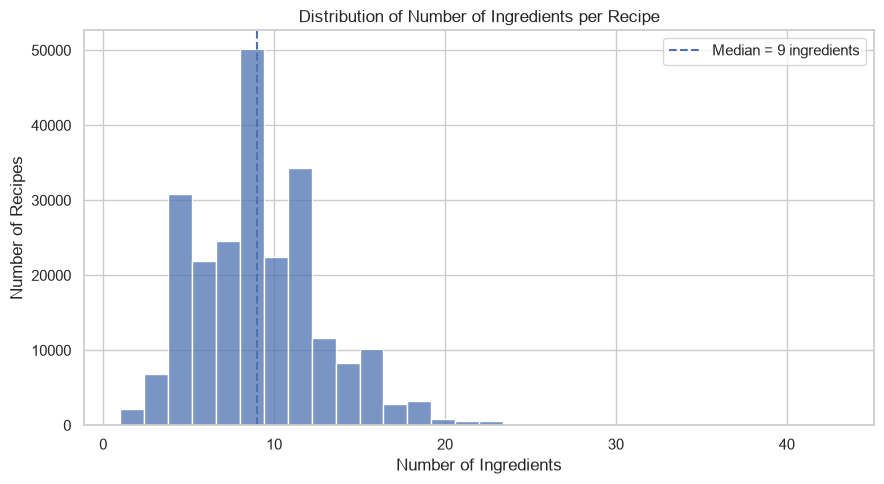

In [33]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=recipes_clean,
    x="n_ingredients",
    bins=30
)

plt.axvline(
    recipes_clean["n_ingredients"].median(),
    linestyle="--",
    label="Median = 9 ingredients"
)

plt.title("Distribution of Number of Ingredients per Recipe")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

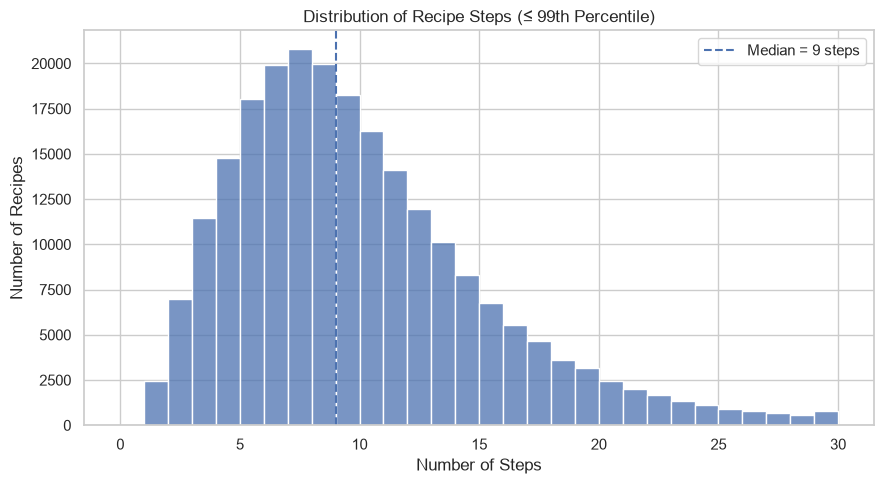

In [34]:
steps_99 = recipes_clean["n_steps"].quantile(0.99)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=recipes_clean[recipes_clean["n_steps"] <= steps_99],
    x="n_steps",
    bins=30
)

plt.axvline(
    recipes_clean["n_steps"].median(),
    linestyle="--",
    label="Median = 9 steps"
)

plt.title("Distribution of Recipe Steps (≤ 99th Percentile)")
plt.xlabel("Number of Steps")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

Recipe complexity is relatively concentrated for most observations. The median recipe contains 9 ingredients and 9 preparation steps. Approximately 90% of recipes contain 14 or fewer ingredients and 17 or fewer steps, while 99% contain no more than 20 ingredients and 30 steps.

The number of ingredients and preparation steps may provide useful indicators of recipe complexity for the recommendation system. Users seeking convenient meals may prefer recipes with fewer ingredients and steps, while other users may be more receptive to complex recipes.

In [35]:
complexity_corr = recipes_clean[
    ["n_ingredients", "n_steps"]
].corr()

complexity_corr

,n_ingredients,n_steps
n_ingredients,1.000000,0.427705
n_steps,0.427705,1.000000


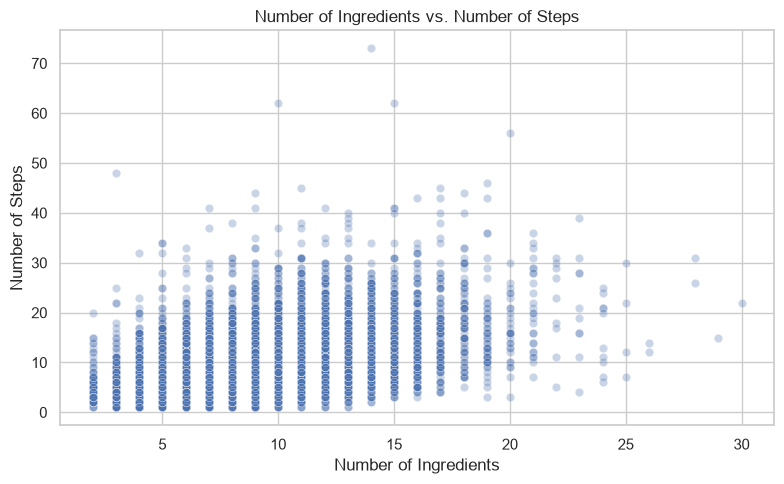

In [36]:
recipe_sample = recipes_clean.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=recipe_sample,
    x="n_ingredients",
    y="n_steps",
    alpha=0.3
)

plt.title("Number of Ingredients vs. Number of Steps")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Steps")
plt.tight_layout()
plt.show()

The number of ingredients and preparation steps have a moderate positive correlation of approximately 0.43. Recipes with more ingredients therefore tend to require more preparation steps, although substantial variation remains.

This suggests that both variables capture related but distinct aspects of recipe complexity. Consequently, both may provide useful information for modeling user preferences rather than treating either variable as a substitute for the other.

### 5.6 Nutritional Characteristics

The `nutrition` field contains seven nutritional measures stored together as a string representation of a list. These values are separated into individual features to make them suitable for exploratory analysis and downstream recommendation modeling.

In [37]:
import ast

nutrition_cols = [
    "calories",
    "total_fat_pct",
    "sugar_pct",
    "sodium_pct",
    "protein_pct",
    "saturated_fat_pct",
    "carbohydrates_pct"
]

nutrition_values = recipes_clean["nutrition"].apply(ast.literal_eval)

nutrition_df = pd.DataFrame(
    nutrition_values.tolist(),
    columns=nutrition_cols,
    index=recipes_clean.index
)

recipes_clean = pd.concat(
    [recipes_clean, nutrition_df],
    axis=1
)

recipes_clean[nutrition_cols].head()

,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [38]:
recipes_clean[nutrition_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   calories           231637 non-null  float64
 1   total_fat_pct      231637 non-null  float64
 2   sugar_pct          231637 non-null  float64
 3   sodium_pct         231637 non-null  float64
 4   protein_pct        231637 non-null  float64
 5   saturated_fat_pct  231637 non-null  float64
 6   carbohydrates_pct  231637 non-null  float64
dtypes: float64(7)
memory usage: 12.4 MB


In [39]:
recipes_clean[nutrition_cols].describe().round(2)

,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
count,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00
mean,473.94,36.08,84.30,30.15,34.68,45.59,15.56
std,1189.71,77.80,800.08,131.96,58.47,98.24,81.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,174.40,8.00,9.00,5.00,7.00,7.00,4.00
50%,313.40,20.00,25.00,14.00,18.00,23.00,9.00
75%,519.70,41.00,68.00,33.00,51.00,52.00,16.00
max,434360.20,17183.00,362729.00,29338.00,6552.00,10395.00,36098.00


In [40]:
recipes_clean[
    ["name", "calories", "total_fat_pct", "sugar_pct",
     "sodium_pct", "protein_pct", "saturated_fat_pct",
     "carbohydrates_pct"]
].sort_values("calories", ascending=False).head(15)

,name,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
209453,tennessee moonshine,434360.2,1293.0,362729.0,1324.0,3961.0,590.0,36098.0
70467,deep fried prime rib,101614.7,17183.0,0.0,230.0,1271.0,10395.0,1.0
165504,powdered hot cocoa mix,45609.0,3379.0,16901.0,1478.0,4356.0,6875.0,1453.0
137181,mmmmmmmmilky way cake,44239.8,2036.0,17306.0,2705.0,936.0,1441.0,2565.0
34023,caledonian wedding cake,43924.6,2556.0,18943.0,841.0,1103.0,4941.0,2233.0
141997,my mercy strawberry cake,42951.6,2343.0,1544.0,2405.0,886.0,2155.0,2315.0
78689,easy easy friendship cake,40159.2,1922.0,1024.0,2386.0,810.0,1084.0,2275.0
182816,scott hibb s amazing whiskey grilled baby back...,38680.1,4317.0,185.0,686.0,6540.0,4960.0,18.0
199615,steph s pork riblets,38662.3,4331.0,77.0,809.0,6552.0,4969.0,8.0
139058,moonshine easy,36188.8,106.0,30260.0,80.0,329.0,48.0,3007.0


In [41]:
recipes_clean[nutrition_cols].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
0.50,313.40,20.0,25.00,14.0,18.0,23.0,9.0
0.75,519.70,41.0,68.00,33.0,51.0,52.0,16.0
0.90,843.60,73.0,160.00,61.0,83.0,98.0,28.0
0.95,1268.72,112.0,269.00,90.0,107.0,147.0,43.0
0.99,3516.96,302.0,1141.64,219.0,188.0,404.0,154.0


In [42]:
print(
    "Recipes with 0 calories:",
    (recipes_clean["calories"] == 0).sum()
)

recipes_clean.loc[
    recipes_clean["calories"] == 0,
    ["name", "calories", "ingredients", "nutrition"]
].head(15)

Recipes with 0 calories: 53


,name,calories,ingredients,nutrition
4707,amazing stain remover,0.0,"['cold water', 'laundry detergent', 'bleach']","[0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0]"
10758,authentic german black bread schwarzbrot,0.0,"['water', 'sourdough starter', 'rye berries', ...","[0.0, 0.0, 0.0, 145.0, 0.0, 0.0, 0.0]"
19827,bee or wasp sting soother,0.0,"['baking soda', 'water']","[0.0, 0.0, 0.0, 104.0, 0.0, 0.0, 0.0]"
28942,brining solution for poultry and meat,0.0,"['cold water', 'kosher salt']","[0.0, 0.0, 0.0, 295.0, 0.0, 0.0, 0.0]"
37985,cedar planked anything,0.0,"['cedar plank', 'water', 'salt', 'plastic wrap...","[0.0, 0.0, 0.0, 293.0, 0.0, 0.0, 0.0]"
56738,collards southern style,0.0,"['collard greens', 'ham hock', 'salt', 'pepper...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
72469,dishwasher detergent,0.0,"['cleaner', 'baking soda', 'lemons']","[0.0, 0.0, 0.0, 77.0, 0.0, 0.0, 0.0]"
73643,dried morel mushrooms,0.0,"['morel', 'water', 'salt']","[0.0, 0.0, 0.0, 4720.0, 0.0, 0.0, 0.0]"
73763,dry aged steak at home,0.0,"['rib eye steak', 'coarse sea salt']","[0.0, 0.0, 0.0, 72.0, 0.0, 0.0, 0.0]"
77164,easy microwave popcorn,0.0,"['popcorn', 'salt']","[0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0]"


Nutritional characteristics exhibit substantial right-skewness. For example, the median recipe contains 313.4 calories, compared with a mean of 473.9 calories, while several nutritional measures contain extremely large maximum values. Because some recipes may represent unusually large quantities or concentrated ingredients, extreme nutritional values are investigated before determining whether they represent valid observations or data-quality issues.

In [43]:
# Flag recipes with potentially unreliable nutrition information
recipes_clean["nutrition_valid"] = recipes_clean["calories"] > 0

print("Valid nutrition records:",
      recipes_clean["nutrition_valid"].sum())

print("Flagged nutrition records:",
      (~recipes_clean["nutrition_valid"]).sum())

Valid nutrition records: 231584
Flagged nutrition records: 53


In [44]:
nutrition_clean = recipes_clean[
    recipes_clean["nutrition_valid"]
].copy()

Nutritional measures are strongly right-skewed, with a small number of extremely large values. Because some recipes represent large batches, mixes, concentrated products, or foods with unusual serving definitions, extreme values were retained rather than classified as errors solely on the basis of magnitude.

A total of 53 recipes report zero calories. Inspection showed that these records include both non-food entries and foods that would ordinarily contain calories, suggesting that zero may sometimes reflect unavailable or unreliable nutritional information. These recipes were retained, but were flagged and excluded from nutrition-specific analyses.

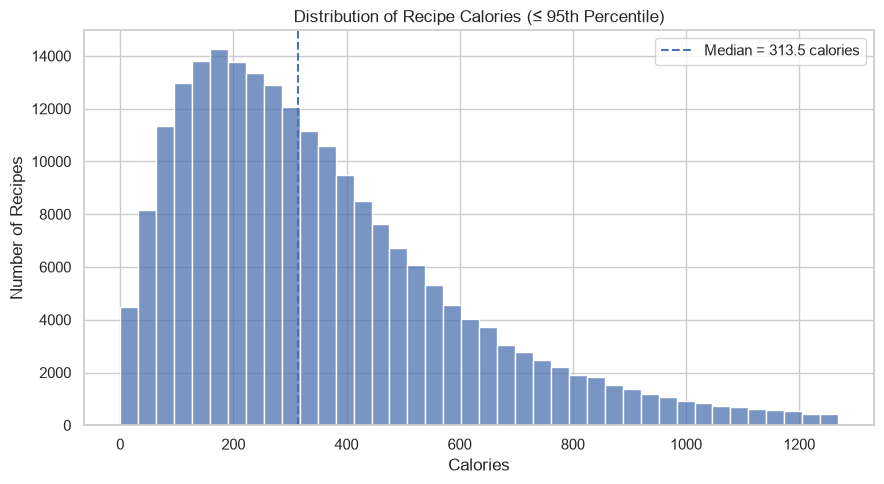

In [45]:
calories_95 = nutrition_clean["calories"].quantile(0.95)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=nutrition_clean[
        nutrition_clean["calories"] <= calories_95
    ],
    x="calories",
    bins=40
)

plt.axvline(
    nutrition_clean["calories"].median(),
    linestyle="--",
    label=f"Median = {nutrition_clean['calories'].median():.1f} calories"
)

plt.title("Distribution of Recipe Calories (≤ 95th Percentile)")
plt.xlabel("Calories")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

Calorie content is strongly right-skewed. The median recipe contains approximately 313 calories, while 75% contain approximately 520 calories or fewer. A relatively small number of recipes contain substantially larger reported calorie values, causing the mean to exceed the median.

Nutritional characteristics may provide useful information for personalization because users may differ in their preferences for lower-calorie, higher-protein, lower-sodium, or other nutritional profiles.

### 5.7 Recipe Tags

Recipe tags provide information about characteristics such as cuisine, dietary categories, preparation style, and meal type. Examining tag frequency helps identify the most common characteristics represented in the recipe collection.

In [46]:
# Convert tag strings to lists
recipes_clean["tags_list"] = recipes_clean["tags"].apply(ast.literal_eval)

recipes_clean[["name", "tags_list"]].head()

,name,tags_list
0,arriba baked winter squash mexican style,"[60-minutes-or-less, time-to-make, course, mai..."
1,a bit different breakfast pizza,"[30-minutes-or-less, time-to-make, course, mai..."
2,all in the kitchen chili,"[time-to-make, course, preparation, main-dish,..."
3,alouette potatoes,"[60-minutes-or-less, time-to-make, course, mai..."
4,amish tomato ketchup for canning,"[weeknight, time-to-make, course, main-ingredi..."


In [47]:
from collections import Counter

tag_counts = Counter(
    tag
    for tags in recipes_clean["tags_list"]
    for tag in tags
)

top_tags = pd.DataFrame(
    tag_counts.most_common(20),
    columns=["tag", "count"]
)

top_tags

,tag,count
0,preparation,230546
1,time-to-make,225326
2,course,218148
3,main-ingredient,170446
4,dietary,165091
5,easy,126062
6,occasion,114145
7,cuisine,91165
8,low-in-something,85776
9,main-dish,71786


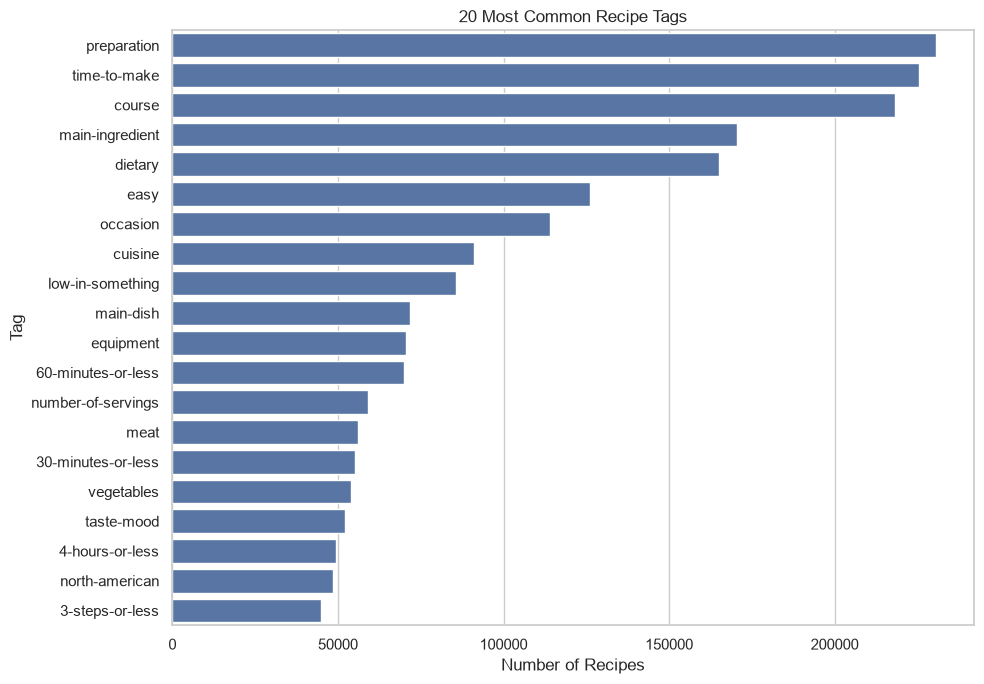

In [48]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_tags,
    x="count",
    y="tag"
)

plt.title("20 Most Common Recipe Tags")
plt.xlabel("Number of Recipes")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

The most frequent recipe tags are broad organizational categories such as `preparation`, `time-to-make`, `course`, and `main-ingredient`, which occur across a large proportion of recipes. More specific tags describe characteristics such as difficulty, preparation time, cuisine, dietary properties, and primary ingredients.

This suggests that tags vary in their usefulness for personalization. Broad tags may provide limited discrimination between recipes, whereas more specific tags such as cuisine, dietary preference, meal type, and preparation time may provide stronger signals of user preference.

### 5.8 Ingredient Frequency

Ingredients represent another important source of information for personalized recommendations. Frequently occurring ingredients are examined to understand the composition of the recipe collection and identify ingredients that may be useful for modeling user preferences.

In [49]:
recipes_clean["ingredients_list"] = (
    recipes_clean["ingredients"].apply(ast.literal_eval)
)

recipes_clean[
    ["name", "ingredients_list"]
].head()

,name,ingredients_list
0,arriba baked winter squash mexican style,"[winter squash, mexican seasoning, mixed spice..."
1,a bit different breakfast pizza,"[prepared pizza crust, sausage patty, eggs, mi..."
2,all in the kitchen chili,"[ground beef, yellow onions, diced tomatoes, t..."
3,alouette potatoes,"[spreadable cheese with garlic and herbs, new ..."
4,amish tomato ketchup for canning,"[tomato juice, apple cider vinegar, sugar, sal..."


In [50]:
ingredient_counts = Counter(
    ingredient
    for ingredients in recipes_clean["ingredients_list"]
    for ingredient in ingredients
)

top_ingredients = pd.DataFrame(
    ingredient_counts.most_common(20),
    columns=["ingredient", "count"]
)

top_ingredients

,ingredient,count
0,salt,85746
1,butter,54975
2,sugar,44535
3,onion,39065
4,water,34914
5,eggs,33761
6,olive oil,32822
7,flour,26266
8,milk,25786
9,garlic cloves,25748


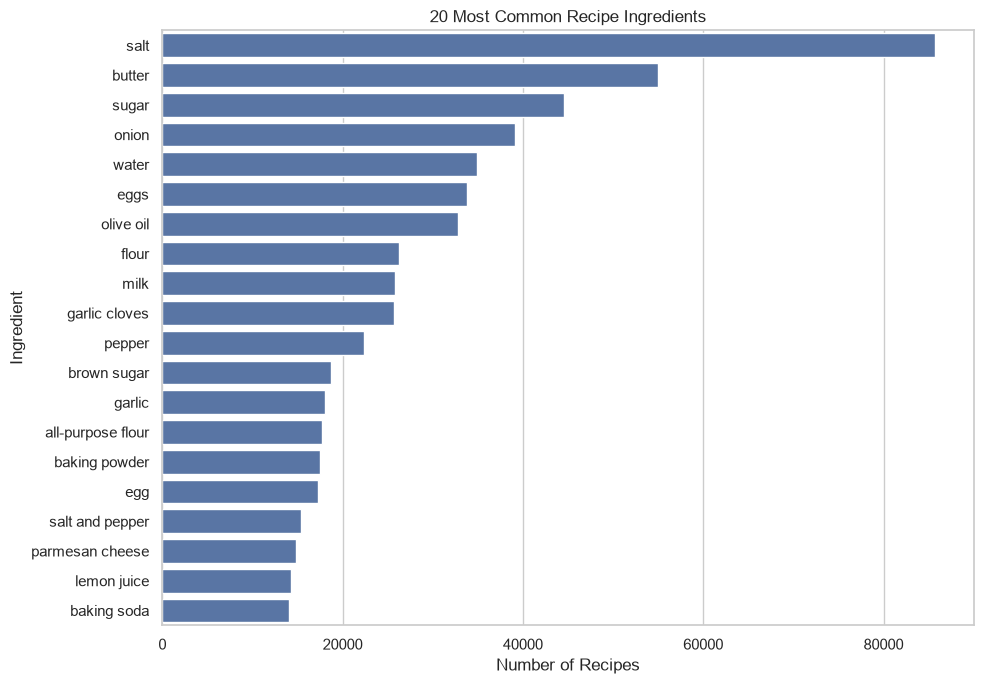

In [51]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_ingredients,
    x="count",
    y="ingredient"
)

plt.title("20 Most Common Recipe Ingredients")
plt.xlabel("Number of Recipes")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

Common pantry staples dominate the ingredient distribution, with salt appearing most frequently, followed by butter, sugar, onion, water, eggs, and olive oil. The results also reveal variations in ingredient naming, such as `garlic` and `garlic cloves` or `egg` and `eggs`.

Ingredient information may provide a valuable signal for personalized recommendation, although additional normalization may be beneficial if ingredients are incorporated directly into the model.

### 5.9 Recipe Characteristics and User Ratings

To investigate whether observable recipe characteristics are associated with user preferences, explicit ratings are joined with recipe-level information. This allows rating behavior to be compared across characteristics such as preparation time, recipe complexity, and nutritional content.

In [52]:
rating_recipe = ratings_clean.merge(
    recipes_clean[
        [
            "id",
            "minutes",
            "n_steps",
            "n_ingredients",
            "calories",
            "protein_pct",
            "tags_list",
            "ingredients_list"
        ]
    ],
    left_on="recipe_id",
    right_on="id",
    how="left"
)

print("Merged observations:", rating_recipe.shape)
rating_recipe.head()

Merged observations: (1071520, 13)


,user_id,recipe_id,date,rating,review,id,minutes,n_steps,n_ingredients,calories,protein_pct,tags_list,ingredients_list
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,40893,495.0,4,9,204.8,24.0,"[weeknight, time-to-make, course, main-ingredi...","[great northern beans, yellow onion, diced gre..."
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",40893,495.0,4,9,204.8,24.0,"[weeknight, time-to-make, course, main-ingredi...","[great northern beans, yellow onion, diced gre..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,44394,20.0,5,4,132.3,4.0,"[30-minutes-or-less, time-to-make, course, mai...","[devil's food cake mix, vegetable oil, eggs, r..."
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,85009,10.0,3,13,2786.2,161.0,"[15-minutes-or-less, time-to-make, course, mai...","[mayonnaise, salsa, cheddar cheese, refried be..."
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",85009,10.0,3,13,2786.2,161.0,"[15-minutes-or-less, time-to-make, course, mai...","[mayonnaise, salsa, cheddar cheese, refried be..."


In [53]:
print(
    "Ratings without matching recipes:",
    rating_recipe["id"].isna().sum()
)

Ratings without matching recipes: 0


In [54]:
rating_recipe.groupby("rating")[
    ["minutes", "n_ingredients", "n_steps", "calories"]
].median().round(2)

,minutes,n_ingredients,n_steps,calories
rating,,,,
1,40.0,8.0,9.0,315.7
2,41.5,9.0,8.0,316.2
3,40.0,9.0,8.0,316.1
4,40.0,9.0,8.0,309.6
5,40.0,9.0,8.0,312.2


Median recipe characteristics are highly similar across rating levels. Typical preparation time remains approximately 40 minutes regardless of rating, while the median number of ingredients, number of steps, and calorie content also vary very little between ratings of 1 through 5.

These results suggest that simple recipe characteristics alone do not strongly distinguish highly rated from poorly rated recipes. This supports the need for personalized recommendation rather than assuming that characteristics such as shorter preparation time, fewer ingredients, or lower calorie content are universally preferred. Individual users may value these characteristics differently.

### 5.10 Average Rating vs. Number of Ratings

In [55]:
recipe_rating_stats = (
    ratings_clean
    .groupby("recipe_id")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

recipe_rating_stats.describe().round(2)

,recipe_id,mean_rating,rating_count
count,226590.00,226590.00,226590.00
mean,220836.60,4.58,4.73
std,140700.50,0.63,16.58
min,38.00,1.00,1.00
25%,99270.25,4.33,1.00
50%,205806.00,4.89,2.00
75%,331825.75,5.00,4.00
max,537716.00,5.00,1496.00


In [56]:
print("Recipes with 1 rating:",
      (recipe_rating_stats["rating_count"] == 1).sum())

print("Recipes with fewer than 5 ratings:",
      (recipe_rating_stats["rating_count"] < 5).sum())

print("Recipes with at least 10 ratings:",
      (recipe_rating_stats["rating_count"] >= 10).sum())

print("Recipes with at least 100 ratings:",
      (recipe_rating_stats["rating_count"] >= 100).sum())

Recipes with 1 rating: 91698
Recipes with fewer than 5 ratings: 175612
Recipes with at least 10 ratings: 20060
Recipes with at least 100 ratings: 711


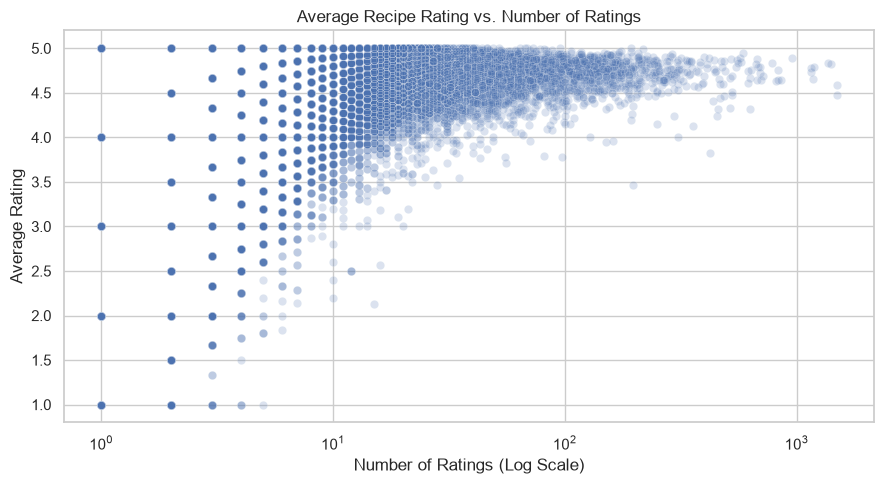

In [93]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=recipe_rating_stats,
    x="rating_count",
    y="mean_rating",
    alpha=0.2
)

plt.xscale("log")

plt.title("Average Recipe Rating vs. Number of Ratings")
plt.xlabel("Number of Ratings (Log Scale)")
plt.ylabel("Average Rating")
plt.tight_layout()

plt.savefig(
    "../reports/figures/recipe_rating_vs_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Recipe-level rating information is highly sparse. The median rated recipe has only 2 ratings, and 91,698 recipes have only a single rating. Overall, 175,612 recipes have fewer than 5 ratings, while only 711 recipes have at least 100 ratings.

The scatterplot demonstrates substantial uncertainty among recipes with few observations. Recipes with only a small number of ratings exhibit average ratings across nearly the entire 1–5 scale, whereas recipes with many ratings have considerably more stable average ratings.

This is particularly relevant for a Bayesian recommendation framework because raw average ratings do not account for differences in the amount of evidence available. For example, a recipe with one 5-star rating and a recipe with hundreds of ratings averaging near 5 stars should not necessarily be treated as equally certain. Bayesian modeling can account for this uncertainty by allowing estimates based on limited observations to be influenced more strongly by prior information, while estimates supported by more data are driven more strongly by the observed ratings.

### 5.11 User-level sparsity

In [58]:
user_activity = (
    ratings_clean
    .groupby("user_id")
    .size()
)

user_sparsity = pd.Series({
    "1 rating": (user_activity == 1).sum(),
    "Fewer than 5 ratings": (user_activity < 5).sum(),
    "At least 5 ratings": (user_activity >= 5).sum(),
    "At least 10 ratings": (user_activity >= 10).sum(),
    "At least 50 ratings": (user_activity >= 50).sum(),
    "At least 100 ratings": (user_activity >= 100).sum()
})

user_sparsity

1 rating                140318
Fewer than 5 ratings    174080
At least 5 ratings       22018
At least 10 ratings      12035
At least 50 ratings       2669
At least 100 ratings      1360
dtype: int64

In [59]:
(user_sparsity / user_activity.size * 100).round(2)

1 rating                71.56
Fewer than 5 ratings    88.77
At least 5 ratings      11.23
At least 10 ratings      6.14
At least 50 ratings      1.36
At least 100 ratings     0.69
dtype: float64

User interaction history is highly sparse. Of the 196,098 users with explicit ratings, 140,318 (71.56%) have rated only one recipe, and 88.77% have provided fewer than five ratings. Only 6.14% of users have at least 10 ratings, while fewer than 1% have at least 100.

This sparsity presents a significant challenge for personalized recommendation because the system has limited information about the preferences of most users. It also motivates the Bayesian approach used in this project. For users with limited interaction histories, prior information can contribute more strongly to preference estimates. As additional ratings become available, posterior estimates can increasingly reflect the individual user's observed preferences. This provides a natural mechanism for adapting recommendations as evidence about a user's preferences accumulates.

### 5.12 User Rating Behavior

To examine differences in how users apply the rating scale, average ratings were calculated for users with at least five explicit ratings. Restricting the analysis to users with multiple interactions reduces the influence of averages based on very limited observations.

In [60]:
user_rating_stats = (
    ratings_clean
    .groupby("user_id")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

active_users = user_rating_stats[
    user_rating_stats["rating_count"] >= 5
]

active_users["mean_rating"].describe().round(2)

count    22018.00
mean         4.65
std          0.37
min          1.00
25%          4.49
50%          4.75
75%          4.93
max          5.00
Name: mean_rating, dtype: float64

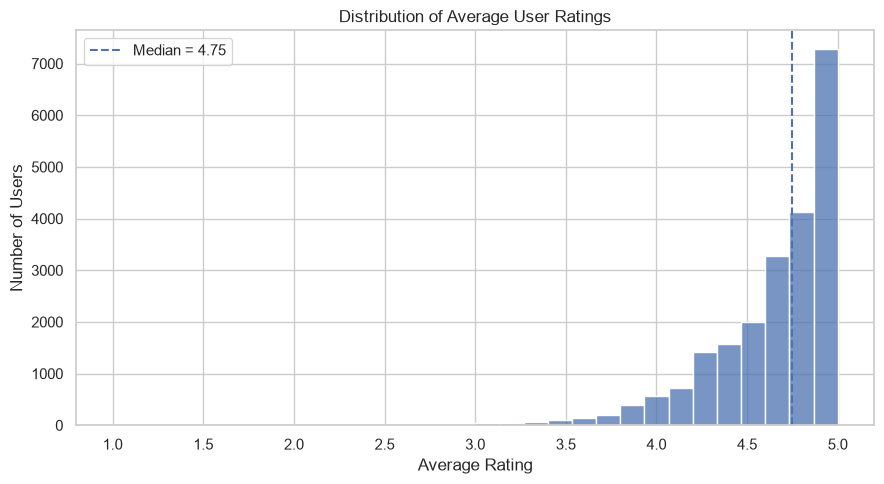

In [94]:
plt.figure(figsize=(9, 5))

sns.histplot(
    active_users["mean_rating"],
    bins=30
)

plt.axvline(
    active_users["mean_rating"].median(),
    linestyle="--",
    label=f"Median = {active_users['mean_rating'].median():.2f}"
)

plt.title("Distribution of Average User Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/figures/user_average_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Among users with at least five explicit ratings, average ratings are strongly concentrated toward the upper end of the rating scale. The median user average is 4.75, with 50% of users having average ratings between approximately 4.49 and 4.93. However, some users exhibit substantially lower average ratings, indicating variation in how users apply the rating scale.

This pattern highlights two challenges for personalized recommendation. First, the strong concentration of ratings near 5 creates a class imbalance in the preference signal. Second, users differ in their baseline rating behavior. A personalized model should therefore account for user-specific tendencies rather than interpreting the same numerical rating identically across all users.

## 6. Data Preparation for Modeling

Based on the exploratory analysis, the datasets are prepared for downstream recommendation modeling. Cleaning decisions are designed to preserve as much useful information as possible while distinguishing between valid preference signals and potentially unreliable or missing information.

The following decisions are applied:

- Ratings of 0 are excluded from explicit-rating modeling because inspection indicates that they represent interactions or reviews without an explicit 1–5 rating.
- Ratings from 1 through 5 are retained as explicit user preference signals.
- Recipes with missing names are retained after replacing the single missing recipe name with a placeholder value.
- Missing recipe descriptions are retained because descriptions are not required for the primary recommendation model.
- Zero-minute preparation times are treated as unavailable or unreliable preparation-time information rather than true zero-minute recipes.
- Extreme preparation-time and nutrition values are retained rather than automatically removed because some may correspond to valid large-batch, preservation, or specialty recipes.
- Zero-calorie recipes are flagged as having potentially unreliable nutrition information and can be excluded from nutrition-specific analyses without removing the recipes themselves.
- Recipe tags and ingredients are converted from string representations into structured lists for potential feature extraction.

In [62]:
modeling_data = ratings_clean.merge(
    recipes_clean[
        [
            "id",
            "minutes",
            "n_steps",
            "n_ingredients",
            "calories",
            "protein_pct",
            "tags_list",
            "ingredients_list"
        ]
    ],
    left_on="recipe_id",
    right_on="id",
    how="inner"
)

In [63]:
print(modeling_data.shape)
modeling_data.info()
modeling_data.head()

(1071520, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1071520 entries, 0 to 1071519
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   user_id           1071520 non-null  int64         
 1   recipe_id         1071520 non-null  int64         
 2   date              1071520 non-null  datetime64[us]
 3   rating            1071520 non-null  int64         
 4   review            1071351 non-null  str           
 5   id                1071520 non-null  int64         
 6   minutes           1067263 non-null  float64       
 7   n_steps           1071520 non-null  int64         
 8   n_ingredients     1071520 non-null  int64         
 9   calories          1071520 non-null  float64       
 10  protein_pct       1071520 non-null  float64       
 11  tags_list         1071520 non-null  object        
 12  ingredients_list  1071520 non-null  object        
dtypes: datetime64[us](1), float64(3), int64

,user_id,recipe_id,date,rating,review,id,minutes,n_steps,n_ingredients,calories,protein_pct,tags_list,ingredients_list
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,40893,495.0,4,9,204.8,24.0,"[weeknight, time-to-make, course, main-ingredi...","[great northern beans, yellow onion, diced gre..."
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",40893,495.0,4,9,204.8,24.0,"[weeknight, time-to-make, course, main-ingredi...","[great northern beans, yellow onion, diced gre..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,44394,20.0,5,4,132.3,4.0,"[30-minutes-or-less, time-to-make, course, mai...","[devil's food cake mix, vegetable oil, eggs, r..."
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,85009,10.0,3,13,2786.2,161.0,"[15-minutes-or-less, time-to-make, course, mai...","[mayonnaise, salsa, cheddar cheese, refried be..."
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",85009,10.0,3,13,2786.2,161.0,"[15-minutes-or-less, time-to-make, course, mai...","[mayonnaise, salsa, cheddar cheese, refried be..."


### 6.1 Dietary Features

Candidate dietary tags are examined before feature construction to determine their prevalence in the recipe dataset.

In [64]:
dietary_tags = [
    "vegetarian",
    "vegan",
    "gluten-free",
    "dairy-free",
    "low-carb",
    "low-fat",
    "healthy"
]

for tag in dietary_tags:
    count = recipes_clean["tags_list"].apply(
        lambda tags: tag in tags
    ).sum()

    print(f"{tag}: {count:,}")

vegetarian: 35,651
vegan: 10,012
gluten-free: 5,743
dairy-free: 195
low-carb: 42,189
low-fat: 22,170
healthy: 40,340


Most candidate dietary tags have sufficient representation to support user-preference modeling. The `dairy-free` tag is substantially less common than the other categories and is excluded as a standalone feature to avoid creating an extremely sparse preference indicator.

In [65]:
dietary_features = {
    "is_vegetarian": "vegetarian",
    "is_vegan": "vegan",
    "is_gluten_free": "gluten-free",
    "is_low_carb": "low-carb",
    "is_low_fat": "low-fat",
    "is_healthy": "healthy"
}

for column, tag in dietary_features.items():
    recipes_clean[column] = recipes_clean["tags_list"].apply(
        lambda tags: int(tag in tags)
    )

In [66]:
dietary_cols = list(dietary_features.keys())

dietary_summary = pd.DataFrame({
    "Count": recipes_clean[dietary_cols].sum(),
    "Percent": (recipes_clean[dietary_cols].mean() * 100).round(2)
})

dietary_summary

,Count,Percent
is_vegetarian,35651,15.39
is_vegan,10012,4.32
is_gluten_free,5743,2.48
is_low_carb,42189,18.21
is_low_fat,22170,9.57
is_healthy,40340,17.42


### 6.2 Meal-Type Features

Before constructing meal-type indicators, the frequency of candidate meal-related tags is examined to ensure adequate representation in the dataset.

In [67]:
meal_tags = [
    "main-dish",
    "desserts",
    "breakfast",
    "lunch",
    "appetizers",
    "side-dishes",
    "snacks",
    "soups-stews",
    "salads"
]

for tag in meal_tags:
    count = recipes_clean["tags_list"].apply(
        lambda tags: tag in tags
    ).sum()

    print(f"{tag}: {count:,}")

main-dish: 71,786
desserts: 43,203
breakfast: 13,655
lunch: 23,800
appetizers: 20,379
side-dishes: 26,902
snacks: 7,159
soups-stews: 11,360
salads: 14,687


All candidate meal-type tags have sufficient representation in the dataset and are retained as binary features.

In [68]:
meal_features = {
    "is_main_dish": "main-dish",
    "is_dessert": "desserts",
    "is_breakfast": "breakfast",
    "is_lunch": "lunch",
    "is_appetizer": "appetizers",
    "is_side_dish": "side-dishes",
    "is_snack": "snacks",
    "is_soup_stew": "soups-stews",
    "is_salad": "salads"
}

for column, tag in meal_features.items():
    recipes_clean[column] = recipes_clean["tags_list"].apply(
        lambda tags: int(tag in tags)
    )

In [69]:
meal_cols = list(meal_features.keys())

meal_summary = pd.DataFrame({
    "Count": recipes_clean[meal_cols].sum(),
    "Percent": (recipes_clean[meal_cols].mean() * 100).round(2)
})

meal_summary

,Count,Percent
is_main_dish,71786,30.99
is_dessert,43203,18.65
is_breakfast,13655,5.89
is_lunch,23800,10.27
is_appetizer,20379,8.80
is_side_dish,26902,11.61
is_snack,7159,3.09
is_soup_stew,11360,4.90
is_salad,14687,6.34


### 6.3 Cuisine Features

Candidate cuisine tags are examined to identify cuisine categories with sufficient representation in the recipe dataset. Cuisine indicators may provide useful signals for personalization because users can have strong preferences for particular regional or cultural food styles.

In [70]:
cuisine_tags = [
    "north-american",
    "italian",
    "mexican",
    "chinese",
    "indian",
    "thai",
    "japanese",
    "greek",
    "french",
    "mediterranean",
    "middle-eastern",
    "spanish",
    "korean",
    "vietnamese"
]

for tag in cuisine_tags:
    count = recipes_clean["tags_list"].apply(
        lambda tags: tag in tags
    ).sum()
    print(f"{tag}: {count:,}")

north-american: 48,479
italian: 7,410
mexican: 6,694
chinese: 2,008
indian: 2,708
thai: 1,208
japanese: 851
greek: 2,391
french: 2,268
mediterranean: 0
middle-eastern: 2,067
spanish: 1,072
korean: 253
vietnamese: 351


The cuisine tags vary substantially in prevalence. To reduce sparsity, cuisine categories with approximately 1,000 or more recipes are retained as standalone features. Very rare cuisine tags are excluded because they would provide limited information for estimating user-level preferences. The `mediterranean` tag is also excluded because it does not appear in the dataset.

In [71]:
cuisine_features = {
    "is_north_american": "north-american",
    "is_italian": "italian",
    "is_mexican": "mexican",
    "is_chinese": "chinese",
    "is_indian": "indian",
    "is_thai": "thai",
    "is_greek": "greek",
    "is_french": "french",
    "is_middle_eastern": "middle-eastern",
    "is_spanish": "spanish"
}

for column, tag in cuisine_features.items():
    recipes_clean[column] = recipes_clean["tags_list"].apply(
        lambda tags: int(tag in tags)
    )

In [72]:
cuisine_cols = list(cuisine_features.keys())

cuisine_summary = pd.DataFrame({
    "Count": recipes_clean[cuisine_cols].sum(),
    "Percent": (recipes_clean[cuisine_cols].mean() * 100).round(2)
})

cuisine_summary

,Count,Percent
is_north_american,48479,20.93
is_italian,7410,3.20
is_mexican,6694,2.89
is_chinese,2008,0.87
is_indian,2708,1.17
is_thai,1208,0.52
is_greek,2391,1.03
is_french,2268,0.98
is_middle_eastern,2067,0.89
is_spanish,1072,0.46


### 6.4 Cooking-Time Features

Cooking time is converted into categorical indicators to capture user preferences for recipes requiring different levels of time commitment. Rather than relying on overlapping time-related tags, mutually exclusive buckets are created directly from the cleaned `minutes` variable.

In [73]:
recipes_clean["minutes"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).round(2)

count     230542.00
mean         128.25
std         2953.31
min            1.00
25%           20.00
50%           40.00
75%           65.00
90%          135.00
95%          255.00
max      1051200.00
Name: minutes, dtype: float64

In [74]:
recipes_clean["time_bucket"] = pd.cut(
    recipes_clean["minutes"],
    bins=[0, 30, 60, 120, float("inf")],
    labels=["quick", "moderate", "long", "extended"],
    include_lowest=True
)

time_summary = pd.DataFrame({
    "Count": recipes_clean["time_bucket"].value_counts().sort_index(),
    "Percent": (
        recipes_clean["time_bucket"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

time_summary

,Count,Percent
time_bucket,,
quick,97959,42.49
moderate,70077,30.40
long,36683,15.91
extended,25823,11.20


The cooking-time buckets are sufficiently represented across the dataset. Quick recipes are the most common, accounting for approximately 42% of recipes with valid cooking times, while extended recipes account for approximately 11%. These categories are retained as features because they provide interpretable measures of users' preferences for different levels of cooking-time commitment.

In [75]:
time_features = {
    "is_quick": "quick",
    "is_moderate_time": "moderate",
    "is_long_time": "long",
    "is_extended_time": "extended"
}

for column, category in time_features.items():
    recipes_clean[column] = (
        recipes_clean["time_bucket"] == category
    ).astype(int)

In [76]:
time_cols = list(time_features.keys())

time_feature_summary = pd.DataFrame({
    "Count": recipes_clean[time_cols].sum(),
    "Percent": (recipes_clean[time_cols].mean() * 100).round(2)
})

time_feature_summary

,Count,Percent
is_quick,97959,42.29
is_moderate_time,70077,30.25
is_long_time,36683,15.84
is_extended_time,25823,11.15


### 6.5 Nutrition Features

The parsed nutrition variables provide additional information about recipe characteristics. Because several nutrition variables contain highly skewed distributions and extreme values, percentile-based categories are used to create interpretable features while reducing the influence of outliers.

In [77]:
nutrition_cols = [
    "calories",
    "total_fat_pct",
    "sugar_pct",
    "sodium_pct",
    "protein_pct",
    "saturated_fat_pct",
    "carbohydrates_pct"
]

recipes_clean[nutrition_cols].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
0.25,174.40,8.0,9.00,5.0,7.0,7.0,4.0
0.50,313.40,20.0,25.00,14.0,18.0,23.0,9.0
0.75,519.70,41.0,68.00,33.0,51.0,52.0,16.0
0.90,843.60,73.0,160.00,61.0,83.0,98.0,28.0
0.95,1268.72,112.0,269.00,90.0,107.0,147.0,43.0
0.99,3516.96,302.0,1141.64,219.0,188.0,404.0,154.0


In [78]:
nutrition_features = {}

for col in nutrition_cols:
    q25 = recipes_clean[col].quantile(0.25)
    q75 = recipes_clean[col].quantile(0.75)

    recipes_clean[f"{col}_level"] = pd.cut(
        recipes_clean[col],
        bins=[-float("inf"), q25, q75, float("inf")],
        labels=["low", "moderate", "high"],
        include_lowest=True
    )

    # Cleaner feature name
    feature_name = col.replace("_pct", "")

    nutrition_features[f"is_low_{feature_name}"] = (col, "low")
    nutrition_features[f"is_high_{feature_name}"] = (col, "high")

In [79]:
for feature, (col, level) in nutrition_features.items():
    recipes_clean[feature] = (
        recipes_clean[f"{col}_level"] == level
    ).astype(int)

In [80]:
nutrition_feature_cols = list(nutrition_features.keys())

nutrition_feature_summary = pd.DataFrame({
    "Count": recipes_clean[nutrition_feature_cols].sum(),
    "Percent": (
        recipes_clean[nutrition_feature_cols].mean() * 100
    ).round(2)
})

nutrition_feature_summary

,Count,Percent
is_low_calories,57945,25.02
is_high_calories,57909,25.00
is_low_total_fat,59942,25.88
is_high_total_fat,56611,24.44
is_low_sugar,59115,25.52
is_high_sugar,57492,24.82
is_low_sodium,62620,27.03
is_high_sodium,56111,24.22
is_low_protein,65042,28.08
is_high_protein,56651,24.46


The resulting nutrition indicators capture approximately the lowest and highest quartiles of each nutritional measure. Percentages do not equal exactly 25% because recipes with values tied at the quartile thresholds are assigned to the same category. This is particularly noticeable for protein and carbohydrate measures. These binary indicators provide interpretable nutritional preference features while limiting the influence of extreme values in the original nutrition variables.

### 6.6 Final Feature Dataset

The engineered dietary, meal-type, cuisine, cooking-time, and nutrition indicators are combined into a feature-ready recipe dataset for downstream Bayesian preference modeling.

In [81]:
final_feature_cols = (
    dietary_cols
    + meal_cols
    + cuisine_cols
    + time_cols
    + nutrition_feature_cols
)

In [82]:
recipe_features = recipes_clean[
    ["id", "name"] + final_feature_cols
].copy()

recipe_features.head()

,id,name,is_vegetarian,is_vegan,is_gluten_free,is_low_carb,is_low_fat,is_healthy,is_main_dish,is_dessert,...,is_low_sugar,is_high_sugar,is_low_sodium,is_high_sodium,is_low_protein,is_high_protein,is_low_saturated_fat,is_high_saturated_fat,is_low_carbohydrates,is_high_carbohydrates
0,137739,arriba baked winter squash mexican style,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,1,0
1,31490,a bit different breakfast pizza,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
2,112140,all in the kitchen chili,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,59389,alouette potatoes,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,44061,amish tomato ketchup for canning,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,1


In [83]:
print("Feature dataset shape:", recipe_features.shape)
print("Number of engineered features:", len(final_feature_cols))
print("Missing values:", recipe_features.isna().sum().sum())
print("Duplicate recipe IDs:", recipe_features["id"].duplicated().sum())

print(
    "Recipes with no active engineered features:",
    (recipe_features[final_feature_cols].sum(axis=1) == 0).sum()
)

Feature dataset shape: (231637, 45)
Number of engineered features: 43
Missing values: 0
Duplicate recipe IDs: 0
Recipes with no active engineered features: 10


In [84]:
feature_validation = pd.DataFrame({
    "Count": recipe_features[final_feature_cols].sum(),
    "Percent": (
        recipe_features[final_feature_cols].mean() * 100
    ).round(2),
    "Min": recipe_features[final_feature_cols].min(),
    "Max": recipe_features[final_feature_cols].max()
})

feature_validation

,Count,Percent,Min,Max
is_vegetarian,35651,15.39,0,1
is_vegan,10012,4.32,0,1
is_gluten_free,5743,2.48,0,1
is_low_carb,42189,18.21,0,1
is_low_fat,22170,9.57,0,1
is_healthy,40340,17.42,0,1
is_main_dish,71786,30.99,0,1
is_dessert,43203,18.65,0,1
is_breakfast,13655,5.89,0,1
is_lunch,23800,10.27,0,1


The final feature dataset contains 231,637 recipes and 43 engineered features, with no missing values or duplicate recipe IDs. Only 10 recipes have no active engineered features, representing a negligible proportion of the dataset. These recipes are retained because they remain valid records and may still be modeled using collaborative-filtering information in the hybrid recommender.

### 6.7 Save Feature-Ready Data

The final recipe feature dataset and cleaned explicit-rating interactions are saved for use by the collaborative filtering and Bayesian modeling components of the project.

In [85]:
from pathlib import Path

processed_dir = Path("../Data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [86]:
recipe_features.to_csv(
    processed_dir / "recipe_features.csv",
    index=False
)

In [87]:
explicit_ratings = ratings_clean[
    ["user_id", "recipe_id", "date", "rating", "review"]
].copy()

explicit_ratings.to_csv(
    processed_dir / "explicit_ratings.csv",
    index=False
)

In [88]:
print("Saved recipe features:")
print(recipe_features.shape)

print("\nSaved explicit ratings:")
print(explicit_ratings.shape)

print("\nFiles:")
for file in processed_dir.iterdir():
    print(file.name)

Saved recipe features:
(231637, 45)

Saved explicit ratings:
(1071520, 5)

Files:
explicit_ratings.csv
recipe_features.csv


### Feature Engineering Summary

The final recipe feature dataset contains 231,637 recipes and 43 engineered features covering dietary preferences, meal categories, cuisines, cooking-time categories, and nutrition characteristics. No missing values or duplicate recipe IDs remain in the feature dataset.

A separate dataset containing 1,071,520 explicit user-recipe ratings (ratings 1–5) was also saved for downstream modeling. These processed datasets provide the feature and interaction inputs needed for the collaborative filtering, Bayesian preference updating, and hybrid recommendation components of the project.

## 7. Validate Reusable Feature Pipeline

The reusable feature-engineering pipeline in `src/features/recipe_features.py` was tested against the cleaned recipe data. The resulting feature dataset matched the expected dimensions and contained no missing values or duplicate recipe IDs.

In [89]:
import sys
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.features.recipe_features import build_recipe_features

recipe_features_test = build_recipe_features(recipes_clean)

print("Shape:", recipe_features_test.shape)
print("Missing values:", recipe_features_test.isna().sum().sum())
print("Duplicate IDs:", recipe_features_test["id"].duplicated().sum())

Shape: (231637, 45)
Missing values: 0
Duplicate IDs: 0


In [91]:
import importlib
import src.data.cleaning as cleaning

importlib.reload(cleaning)

interactions_test_clean = cleaning.clean_interactions(interactions)
recipes_test_clean = cleaning.clean_recipes(recipes)

print("Explicit interactions:", interactions_test_clean.shape)
print(
    "Rating range:",
    interactions_test_clean["rating"].min(),
    "-",
    interactions_test_clean["rating"].max()
)

print("\nRecipes:", recipes_test_clean.shape)
print(
    "Zero/negative cooking times:",
    (recipes_test_clean["minutes"] <= 0).sum()
)
print(
    "Missing cooking times:",
    recipes_test_clean["minutes"].isna().sum()
)
print(
    "Missing recipe names:",
    recipes_test_clean["name"].isna().sum()
)

Explicit interactions: (1071520, 5)
Rating range: 1 - 5

Recipes: (231637, 12)
Zero/negative cooking times: 0
Missing cooking times: 1095
Missing recipe names: 0
